In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

VERİ SETİNİ UTF-8 FORMATINDA OKUMA

In [2]:
df = pd.read_csv("mushrooms_dirty.csv", encoding="utf-8")
print("Veri başarıyla UTF-8 ile okundu.")

Veri başarıyla UTF-8 ile okundu.


ilk 5 satır okuma

In [3]:
print(df.head())

  class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0     p         x           s         n       t    p               f   
1     e         x           s         y       t    a               f   
2     e         b           s         w       t    l               f   
3     p       NaN           y         w       t    p               f   
4     e         x           s         g       f    n               f   

  gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
0            c         n          k  ...                        s   
1            c         b          k  ...                        s   
2            c         b          n  ...                        s   
3            c         n          n  ...                        s   
4            w         b          k  ...                        s   

  stalk-color-above-ring stalk-color-below-ring veil-type veil-color  \
0                      w                      w         p          w   
1       

EKSİK VERİ KONTROLÜ (isna ve notna)

In [4]:
print("\n--- Eksik Veri Kontrolü (isna) ---")
print(df.isna().sum())   

print("\n--- Dolu Veri Kontrolü (notna) ---")
print(df.notna().sum())  


--- Eksik Veri Kontrolü (isna) ---
class                       162
cap-shape                   162
cap-surface                 162
cap-color                   162
bruises                     162
odor                        162
gill-attachment             162
gill-spacing                162
gill-size                   161
gill-color                  162
stalk-shape                 162
stalk-root                  154
stalk-surface-above-ring    162
stalk-surface-below-ring    162
stalk-color-above-ring      162
stalk-color-below-ring      162
veil-type                   162
veil-color                  162
ring-number                 162
ring-type                   162
spore-print-color           162
population                  161
habitat                     162
dtype: int64

--- Dolu Veri Kontrolü (notna) ---
class                       7962
cap-shape                   7962
cap-surface                 7962
cap-color                   7962
bruises                     7962
odor          

VERİ BİRLEŞTİRME

In [5]:
merge_example = df[["class", "odor"]].copy()
merge_example["extra_info"] = "test"

df_merged = df.merge(merge_example, left_index=True, right_index=True, how="left")

print("\n--- Veri Birleştirme Örneği Tamamlandı ---")
print(df_merged.head())


--- Veri Birleştirme Örneği Tamamlandı ---
  class_x cap-shape cap-surface cap-color bruises odor_x gill-attachment  \
0       p         x           s         n       t      p               f   
1       e         x           s         y       t      a               f   
2       e         b           s         w       t      l               f   
3       p       NaN           y         w       t      p               f   
4       e         x           s         g       f      n               f   

  gill-spacing gill-size gill-color  ... veil-type veil-color ring-number  \
0            c         n          k  ...         p          w           o   
1            c         b          k  ...         p          w           o   
2            c         b          n  ...         p          w           o   
3            c         n          n  ...         p          w           o   
4            w         b          k  ...         p          w           o   

  ring-type spore-print-color popula

EKSİK VERİLERİN DOLDURULMASI (Temizleme)

In [6]:
print("\n--- Eksik Veri Doldurma İşlemine Başlanıyor ---")

df.replace("?", np.nan, inplace=True)

invalid_values = ["??", "wrong", "Z", "XXX"]
df.replace(invalid_values, np.nan, inplace=True)

for col in df.columns:
    mode_value = df[col].mode()[0]
    df[col].fillna(mode_value, inplace=True)

print("\n--- Eksik Değerler Mod ile Dolduruldu ---")
print(df.isna().sum())


--- Eksik Veri Doldurma İşlemine Başlanıyor ---

--- Eksik Değerler Mod ile Dolduruldu ---
class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64


GÜNCEL VERİDE NaN KONTROLÜ

In [7]:
print("\n--- NaN Kontrolü (Temizlik Sonrası) ---")
print(df.isna().sum())


--- NaN Kontrolü (Temizlik Sonrası) ---
class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64


 DÖNÜŞTÜRME (Label Encoding)

In [8]:
label_encoders = {}

for col in df.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print("\n--- Encoding Sonrası İlk 5 Satır ---")
print(df.head())



--- Encoding Sonrası İlk 5 Satır ---
   class  cap-shape  cap-surface  cap-color  bruises  odor  gill-attachment  \
0      1          5            2          4        1     6                1   
1      0          5            2          9        1     0                1   
2      0          0            2          8        1     3                1   
3      1          5            3          8        1     6                1   
4      0          5            2          3        0     5                1   

   gill-spacing  gill-size  gill-color  ...  stalk-surface-below-ring  \
0             0          1           4  ...                         2   
1             0          0           4  ...                         2   
2             0          0           5  ...                         2   
3             0          1           5  ...                         2   
4             1          0           4  ...                         2   

   stalk-color-above-ring  stalk-color-below-rin

TEMİZLENMİŞ VERİNİN KAYDEDİLMESİ

In [9]:
df.to_csv("mushrooms_cleaned_final.csv", index=False, encoding="utf-8")
print("\nTEMİZ VERİ SETİ OLUŞTURULDU → mushrooms_cleaned_final.csv")


TEMİZ VERİ SETİ OLUŞTURULDU → mushrooms_cleaned_final.csv


In [10]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA  # Boyut küçültme için
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore', category=FutureWarning) 

print("Hücre 1 çalıştı: Kütüphaneler yüklendi.")

Hücre 1 çalıştı: Kütüphaneler yüklendi.


VERİYİ YÜKLEME

In [11]:
print("--- Adım 1 & 2: Veri Yükleniyor ve Hazırlanıyor ---")
try:
    df = pd.read_csv("mushrooms_cleaned_final.csv")
    print("✓ 'mushrooms_cleaned_final.csv' yüklendi.")
    
    # --- 2. Adım: Veriyi Hazırlama ---
    # Gerçek etiketleri (sonra grafikte kullanmak için) sakla
    y_true_labels = df['class'] 
    
    # Etiketleri at (En önemli değişiklik)
    X_cluster = df.drop('class', axis=1) 
    
    print("✓ 'class' sütunu (etiketler) veri setinden atıldı.")
    print(f"✓ Kümeleme için {X_cluster.shape[1]} özellik kullanılacak.\n")

except FileNotFoundError:
    print("HATA: 'mushrooms_cleaned_final.csv' dosyası bulunamadı.")

--- Adım 1 & 2: Veri Yükleniyor ve Hazırlanıyor ---
✓ 'mushrooms_cleaned_final.csv' yüklendi.
✓ 'class' sütunu (etiketler) veri setinden atıldı.
✓ Kümeleme için 22 özellik kullanılacak.



K-Means Kümeleme Modeli 

In [12]:
print("--- Adım 3: K-Means Kümeleme Modeli Çalıştırılıyor ---")
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X_cluster)
cluster_labels = kmeans.labels_ # Modelin bulduğu kümeler
print("✓ K-Means modeli veriyi 2 gruba (küme) ayırdı.\n")

--- Adım 3: K-Means Kümeleme Modeli Çalıştırılıyor ---
✓ K-Means modeli veriyi 2 gruba (küme) ayırdı.



Sonuçları Analiz Etme

In [13]:
print("--- Adım 4: Kümeleme Sonuçları (Metin) ---")
print("Modelin Bulduğu Küme Dağılımı:")
print(pd.Series(cluster_labels).value_counts())

print("\nSağlama: Bulunan Kümeler vs Gerçek Etiketler (Çapraz Tablo):")
cross_tab = pd.crosstab(y_true_labels, cluster_labels, 
                        rownames=['Gerçek Sınıf (class)'], 
                        colnames=['Bulunan Küme (cluster)'])
print(cross_tab)

--- Adım 4: Kümeleme Sonuçları (Metin) ---
Modelin Bulduğu Küme Dağılımı:
0    6089
1    2035
Name: count, dtype: int64

Sağlama: Bulunan Kümeler vs Gerçek Etiketler (Çapraz Tablo):
Bulunan Küme (cluster)     0     1
Gerçek Sınıf (class)              
0                       3986   306
1                       2103  1729


Görselleştirme İçin Boyut Küçültme 

In [14]:
print("\n--- Adım 5: Görselleştirme için Boyut Küçültme (PCA) ---")
pca = PCA(n_components=2) 
X_pca = pca.fit_transform(X_cluster)
print("✓ 22 özellik, PCA ile 2 özelliğe (Component 1, Component 2) indirgendi.")

# PCA sonuçlarını ve etiketleri tek tabloda topla
pca_df = pd.DataFrame(data=X_pca, columns=['PCA1', 'PCA2'])
pca_df['Bulunan_Kume'] = cluster_labels
pca_df['Gercek_Sınıf'] = y_true_labels


--- Adım 5: Görselleştirme için Boyut Küçültme (PCA) ---
✓ 22 özellik, PCA ile 2 özelliğe (Component 1, Component 2) indirgendi.


Görselleştirme (2 Adet Grafik)


--- Adım 6: Grafikler Oluşturuluyor... ---
✓ 'kumeleme_gorsel.png' dosyası oluşturuldu.


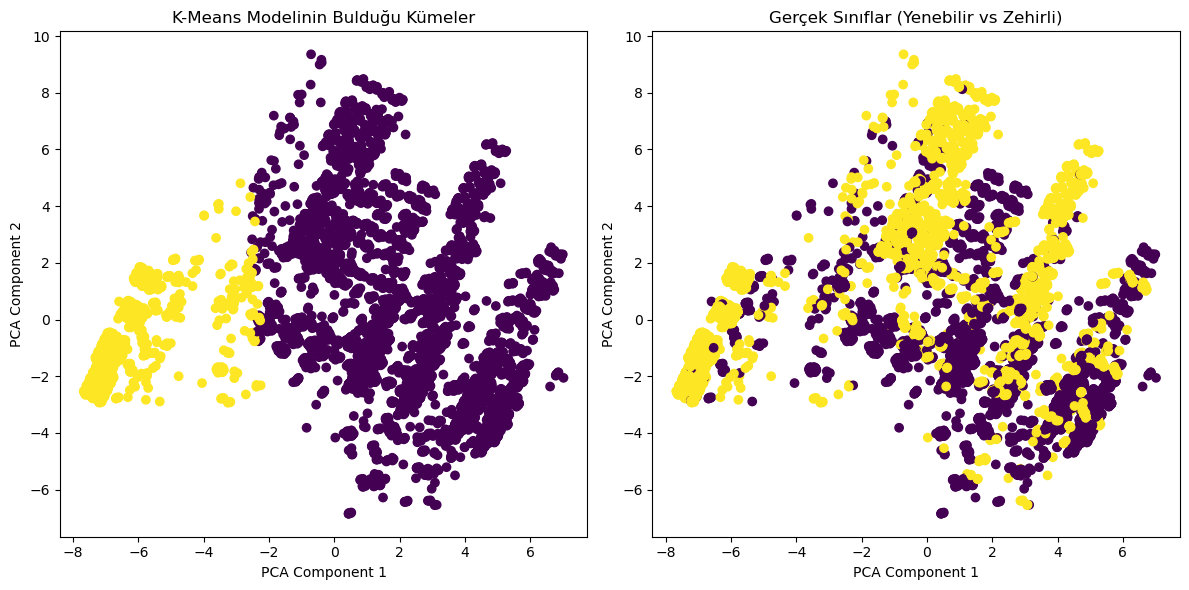

In [15]:
print("\n--- Adım 6: Grafikler Oluşturuluyor... ---")

plt.figure(figsize=(12, 6))

# Grafik 1: Modelin Bulduğu Kümeler
plt.subplot(1, 2, 1) 
plt.scatter(pca_df['PCA1'], pca_df['PCA2'], c=pca_df['Bulunan_Kume'], cmap='viridis')
plt.title('K-Means Modelinin Bulduğu Kümeler')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

# Grafik 2: Gerçek Sınıflar
plt.subplot(1, 2, 2) 
plt.scatter(pca_df['PCA1'], pca_df['PCA2'], c=pca_df['Gercek_Sınıf'], cmap='viridis')
plt.title('Gerçek Sınıflar (Yenebilir vs Zehirli)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

plt.tight_layout()
plt.savefig("kumeleme_gorsel.png") 
print("✓ 'kumeleme_gorsel.png' dosyası oluşturuldu.")

plt.show()

In [16]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np


In [17]:
df = pd.read_csv("mushrooms_cleaned_final.csv")   # <<< TEMİZ DOSYANIN ADINI BURAYA YAZ

print("İlk 5 satır:")
display(df.head())

İlk 5 satır:


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,7,7,0,2,1,4,2,4,5
4,0,5,2,3,0,5,1,1,0,4,...,2,7,7,0,2,1,0,3,0,1


Hedef sütununu ayır

In [18]:
y = df["class"]
X = df.drop("class", axis=1)

Label Encoding

In [19]:
X_encoded = X.copy()
encoders = {}

for col in X_encoded.columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])
    encoders[col] = le

le_y = LabelEncoder()
y_encoded = le_y.fit_transform(y)


Train-test split (%80 eğitim, %20 test)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded,
    test_size=0.2,       # <<< %20 TEST
    random_state=42,
    stratify=y_encoded
)


Random Forest modeli

In [21]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

Tahmin

In [22]:
y_pred = rf.predict(X_test)

 Accuracy

In [23]:
accuracy = accuracy_score(y_test, y_pred)
print(f"\nDoğruluk Oranı (Accuracy): {accuracy:.4f}")


Doğruluk Oranı (Accuracy): 0.9883


Confusion Matrix (görselleştirme)

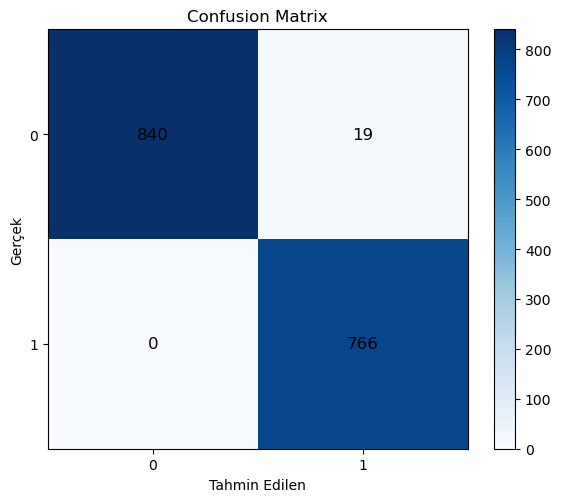

In [24]:
cm = confusion_matrix(y_test, y_pred)
classes = le_y.classes_

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

for i in range(len(cm)):
    for j in range(len(cm[i])):
        plt.text(j, i, cm[i][j], ha='center', va='center', color='black', fontsize=12)

plt.xlabel("Tahmin Edilen")
plt.ylabel("Gerçek")
plt.tight_layout()
plt.show()

Tree-Augmented Naive Bayes ile Mantar Sınıflandırması

Bu projede, mantar özelliklerine göre zehirli/yenilebilir sınıflandırması yapılmıştır. Tree-Augmented Naive Bayes (TAN) algoritması kullanılarak özellikler arası bağımlılıklar da modele dahil edilmiştir.

In [25]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import TreeSearch, BayesianEstimator
from pgmpy.inference import VariableElimination
from sklearn.metrics import accuracy_score

In [26]:
veri = pd.read_csv("mushrooms_cleaned_final.csv")
veri = veri.dropna()  # Eksik verileri temizle

# Tüm sütunları etiketleyerek sayısal hale getir
etiketleyici = LabelEncoder()
for sutun in veri.columns:
    veri[sutun] = etiketleyici.fit_transform(veri[sutun].astype(str))

veri = veri.astype(str)  # pgmpy için string format
veri.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,6,...,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,6,...,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,7,...,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,7,...,2,7,7,0,2,1,4,2,4,5
4,0,5,2,3,0,5,1,1,0,6,...,2,7,7,0,2,1,0,3,0,1


In [27]:
egitim, test = train_test_split(veri, test_size=0.2, random_state=42)

In [28]:
yapici = TreeSearch(egitim, root_node="cap-shape")
dag = yapici.estimate(estimator_type="tan", class_node="class")  # 'class' hedef değişken

Building tree:   0%|          | 0/253.0 [00:00<?, ?it/s]

In [29]:

model = DiscreteBayesianNetwork(dag.edges())
model.fit(egitim)

print("Model başarıyla eğitildi!")

Model başarıyla eğitildi!


Açıklama: TAN yapısına göre model kurulur ve olasılık tabloları öğrenilir.

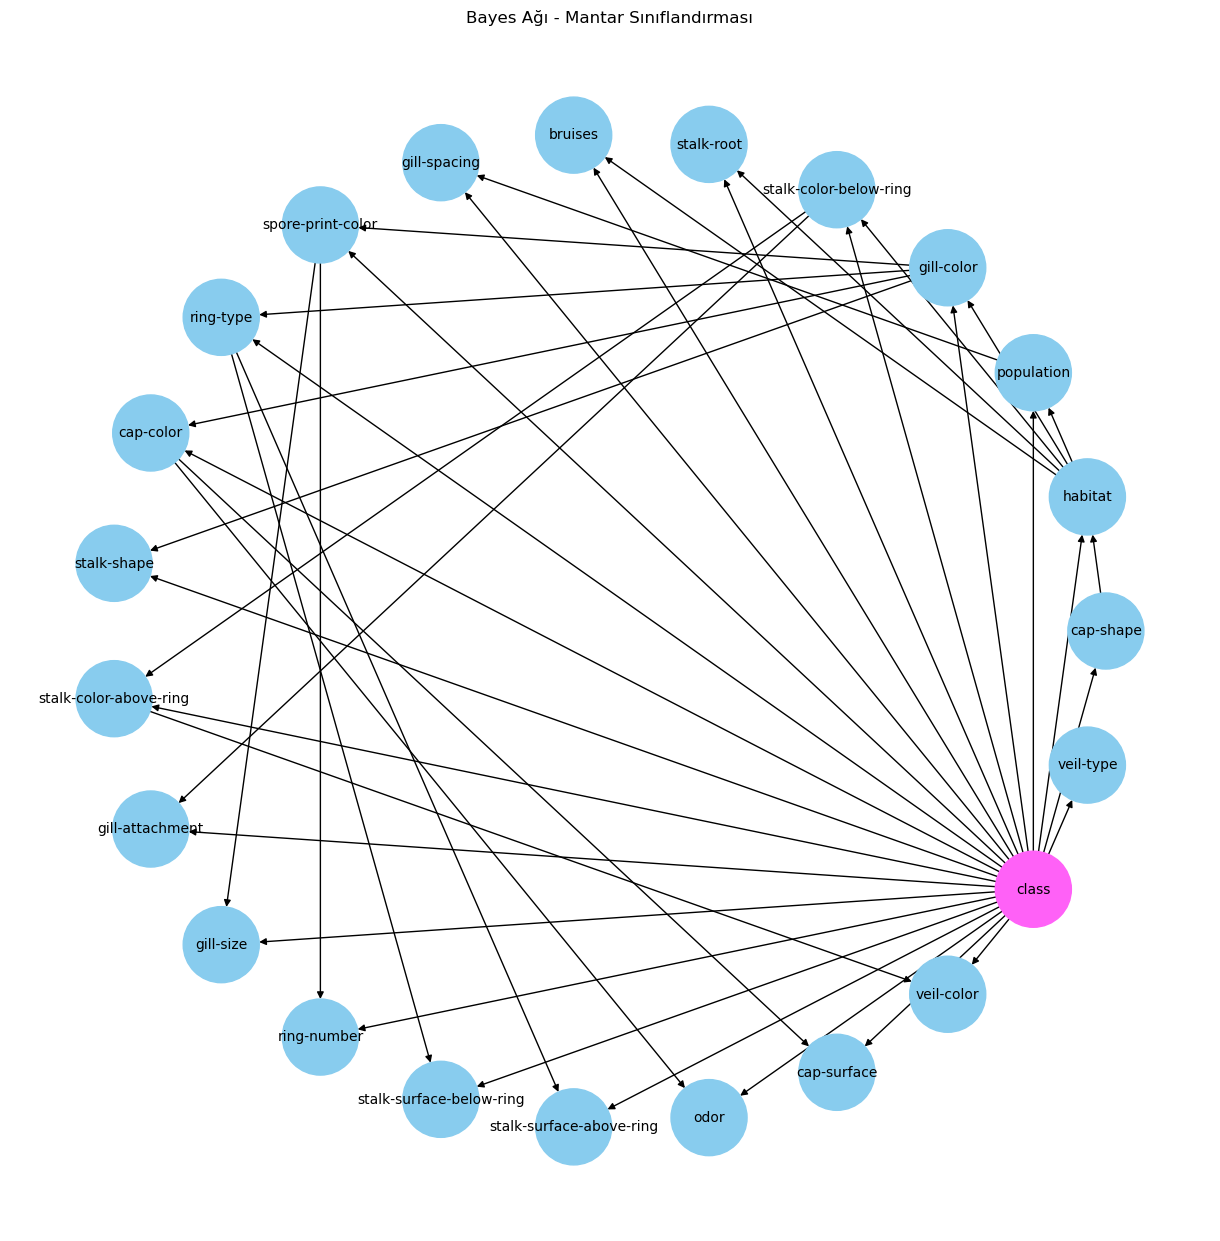

In [30]:
plt.figure(figsize=(12,12))
G = nx.DiGraph()
G.add_edges_from(model.edges())
pos = nx.circular_layout(G)

renkler = ["#FF61F7" if n == "class" else "#88CCEE" for n in G.nodes()]
nx.draw(G, pos=pos, with_labels=True, node_color=renkler, node_size=3000, font_size=10)
plt.title("Bayes Ağı - Mantar Sınıflandırması")
plt.show()

Açıklama: Ağ yapısı çizilir. class düğümü kırmızı, diğerleri mavi renktedir. Bu görseli sunumda kullanabilirsin.

In [31]:
dogruluklar = {}

for sutun in test.columns:
    temp = test.copy()
    temp.drop(sutun, axis=1, inplace=True)
    tahmin = model.predict(temp)[sutun]
    acc = accuracy_score(test[sutun], tahmin)
    dogruluklar[sutun] = acc
    print(f"{sutun} doğruluk: {acc:.2f}")

  0%|          | 0/1613 [00:00<?, ?it/s]

class doğruluk: 0.56


  0%|          | 0/1487 [00:00<?, ?it/s]

cap-shape doğruluk: 0.41


  0%|          | 0/1507 [00:00<?, ?it/s]

...

spore-print-color doğruluk: 0.23


  0%|          | 0/1527 [00:00<?, ?it/s]

population doğruluk: 0.41


  0%|          | 0/1535 [00:00<?, ?it/s]

habitat doğruluk: 0.22


Açıklama: Her sütun için modelin tahmin başarısı ölçülür.

In [32]:
ortalama = np.mean(list(dogruluklar.values()))
print(f"Ortalama doğruluk: {ortalama:.2f}")

Ortalama doğruluk: 0.51


In [33]:
print(f"Model geçerli mi? {model.check_model()}\n")
for cpd in model.get_cpds():
    print(f"{cpd.variable} için CPT:")
    print(cpd)
    print("\n")

Model geçerli mi? True

cap-shape için CPT:
+--------------+----------------------+-----------------------+
| class        | class(0)             | class(1)              |
+--------------+----------------------+-----------------------+
| cap-shape(0) | 0.08974739970282318  | 0.01244416081684748   |
+--------------+----------------------+-----------------------+
| cap-shape(1) | 0.0                  | 0.0009572431397574984 |
+--------------+----------------------+-----------------------+
| cap-shape(2) | 0.3640416047548291   | 0.38544990427568604   |
+--------------+----------------------+-----------------------+
| cap-shape(3) | 0.056166419019316495 | 0.15507338864071474   |
+--------------+----------------------+-----------------------+
| cap-shape(4) | 0.008023774145616641 | 0.0                   |
+--------------+----------------------+-----------------------+
| cap-shape(5) | 0.48202080237741457  | 0.4460753031269943    |
+--------------+----------------------+---------------------

print(f"Model geçerli mi? {model.check_model()}\n")
for cpd in model.get_cpds():
    print(f"{cpd.variable} için CPT:")
    print(cpd)
    print("\n")

In [34]:
inference = VariableElimination(model)
sonuc = inference.query(variables=["class"], evidence={"odor": "3", "cap-color": "5"})
print(sonuc)

+----------+--------------+
| class    |   phi(class) |
+==========+==============+
| class(0) |          nan |
+----------+--------------+
| class(1) |          nan |
+----------+--------------+


Açıklama: Kullanıcıdan belirtiler alınarak mantarın zehirli olup olmadığı tahmin edilir.